In [2]:
# https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/#create-agent-supervisor

from dotenv import load_dotenv

from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

load_dotenv()

tavily_tool = TavilySearchResults(max_results=5)

# This executes code locally, which can be unsafe
repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return result_str

################################ Create Agent Supervisor

from typing import Literal
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from langgraph.graph import MessagesState, END
from langgraph.types import Command

members = ["researcher", "coder"]
options = members + ["FINISH"]

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""
    next: Literal[*options]
    # next: Literal["researcher", "coder", "FINISH"]

llm = ChatOllama(model="qwen3:8b")

class State(MessagesState):
    next: str


def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    if goto == "FINISH":
        goto = END

    return Command(goto=goto, update={"next": goto})


################################ Construct Graph

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent   

research_prompt = "You are a researcher. DO NOT do any math."
research_agent = create_react_agent(
# research_agent = create_structured_chat_agent(
    llm, tools=[tavily_tool], prompt=research_prompt
)
# research_executor = AgentExecutor(agent=research_agent, tools=[tavily_tool])

def research_node(state: State) -> Command[Literal["supervisor"]]:
    # last_message = next((m for m in reversed(state["messages"]) if m["role"] == "user"), None)
    result = research_agent.invoke(state)
    # result = research_agent.invoke({"input": last_message["content"]})
    # result = research_executor.invoke({"input": last_message["content"]})
    # output = result.get("output", "No research results found.")
    return Command(
        update={
            "messages": [HumanMessage(content=result["messages"][-1].content, name="researcher")]
            # "messages": state["messages"] + [{"role": "assistant", "content": output, "name": "researcher"}]
        },
        goto="supervisor",
    )

# NOTE: THIS PERFORMS ARBITRARY CODE EXECUTION, WHICH CAN BE UNSAFE WHEN NOT SANDBOXED
code_agent = create_react_agent(llm, tools=[python_repl_tool])
# code_agent = create_react_agent(llm, tools=[python_repl_tool], prompt=original_prompt)
# code_agent = create_structured_chat_agent(llm, [python_repl_tool], "You are a Python coder.")
# code_executor = AgentExecutor(agent=code_agent, tools=[python_repl_tool])

def code_node(state: State) -> Command[Literal["supervisor"]]:
    # last_message = next((m for m in reversed(state["messages"]) if m["role"] == "user"), None)
    result = code_agent.invoke(state)
    # result = code_agent.invoke({"input": last_message["content"]})
    # last_message = next((m for m in reversed(state["messages"]) if m["role"] == "user"), None)
    # result = code_executor.invoke({"input": last_message["content"]})
    # output = result.get("output", "No code results")
    return Command(
        update={
            "messages": [HumanMessage(content=result["messages"][-1].content, name="coder")]
            # "messages": state["messages"] + [{"role": "assistant", "content": output, "name": "coder"}]
        },
        goto="supervisor",
    )

builder = StateGraph(State)
builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", research_node)
builder.add_node("coder", code_node)
graph = builder.compile()

C:\Users\kevin\AppData\Local\Temp\ipykernel_29740\4082228276.py:13: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)
C:\Users\kevin\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\kevin\AppData\Local\Temp\ipykernel_29740\4082228276.py:81: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.


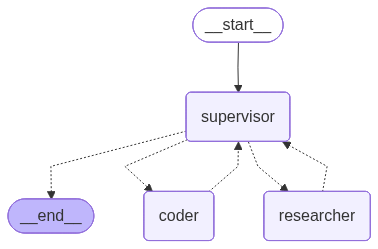

In [3]:
from IPython.display import display, Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    print("Unable to display graph visualization")

In [4]:
# user_message = {"role": "user", "content": "What's the square root of 42?"}
# for s in graph.stream({"messages": [user_message]}, subgraphs=True):
#     print(s)
#     print("----")

for s in graph.stream(
    {
        "messages": [
            (
                "user",
                "Find the latest GDP of New York and California, then calculate the average",
            )
        ]
    },
    subgraphs=True,
):
    print(s)
    print("----")    

((), {'supervisor': {'next': 'researcher'}})
----
(('researcher:ed8ed0fb-bdce-65bb-54a5-76b03155131c',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-01-19T00:49:59.4747836Z', 'done': True, 'done_reason': 'stop', 'total_duration': 162728787900, 'load_duration': 339961400, 'prompt_eval_count': 198, 'prompt_eval_duration': 30618671000, 'eval_count': 434, 'eval_duration': 131470856300, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019bd3b8-6908-7821-af77-96bd3baefa95-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Latest GDP of New York and California 2023'}, 'id': '05d2b007-9fa5-4c79-9d0d-f08d1b54cc3c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 198, 'output_tokens': 434, 'total_tokens': 632})]}})
----
(('researcher:ed8ed0fb-bdce-65bb-54a5-76b03155131c',), {'tools': {'messages': [ToolMessage(content='[{"titl